In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("loan_approval_data.csv")

### Handling missing values 


In [4]:
numerical_cols = df.select_dtypes(include = ["float64"]).columns
categorical_cols = df.select_dtypes(include = ["object"]).columns

In [5]:
from sklearn.impute import SimpleImputer

num_imput = SimpleImputer(strategy = "mean")
df[numerical_cols] = num_imput.fit_transform(df[numerical_cols])

In [6]:
cat_imput = SimpleImputer(strategy = "most_frequent")
df[categorical_cols] = cat_imput.fit_transform(df[categorical_cols])

### EDA

Text(0.5, 1.0, 'Is Loan Approved?')

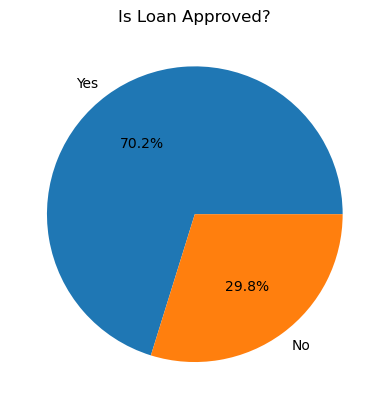

In [8]:
# how balanced our classes are ?

classes_count = df["Loan_Approved"].value_counts()
plt.pie(classes_count, labels= ["Yes", "No"], autopct = "%1.1f%%")
plt.title("Is Loan Approved?")

[Text(0, 0, '621'), Text(0, 0, '379')]

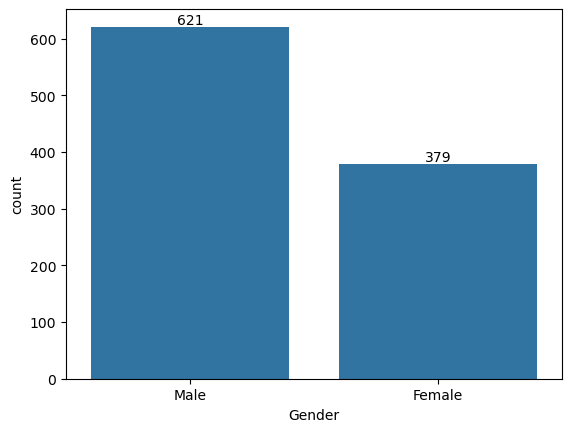

In [9]:
# analyze categories

gender_count = df["Gender"].value_counts()
axs = sns.barplot(gender_count)
axs.bar_label(axs.containers[0])

[Text(0, 0, '517'), Text(0, 0, '294'), Text(0, 0, '189')]

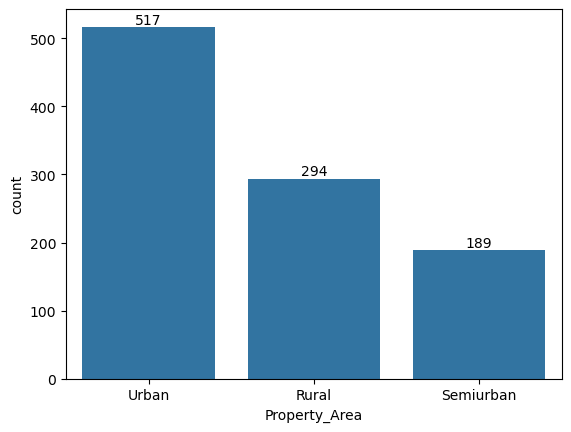

In [10]:
property_area = df["Property_Area"].value_counts()
axs = sns.barplot(property_area)
axs.bar_label(axs.containers[0])

<Axes: xlabel='Credit_Score', ylabel='Count'>

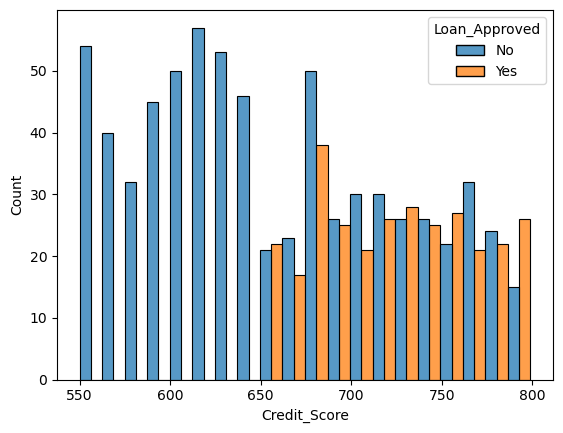

In [11]:
sns.histplot(
    data = df,
    x = "Credit_Score",
    hue = "Loan_Approved",
    bins= 20,
    multiple= "dodge"
)

In [12]:
# droping Applicant_ID (Unnecessary)

df = df.drop(columns = "Applicant_ID")

In [13]:
df

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,Not Graduate,Male,Unemployed,No
996,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


### Encoding

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   int32  
 16  Gender 

In [17]:
# One Hot Encoder

from sklearn.preprocessing import OneHotEncoder

cols = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]

ohe = OneHotEncoder(drop= "first", sparse_output= False, handle_unknown= "ignore")
encoded = ohe.fit_transform(df[cols])
encoded_df = pd.DataFrame(encoded, columns= ohe.get_feature_names_out(cols), index= df.index)

df = pd.concat([df, encoded_df], axis= 1)
df =df.drop(columns = cols)

### correlation Heatmap

<Axes: >

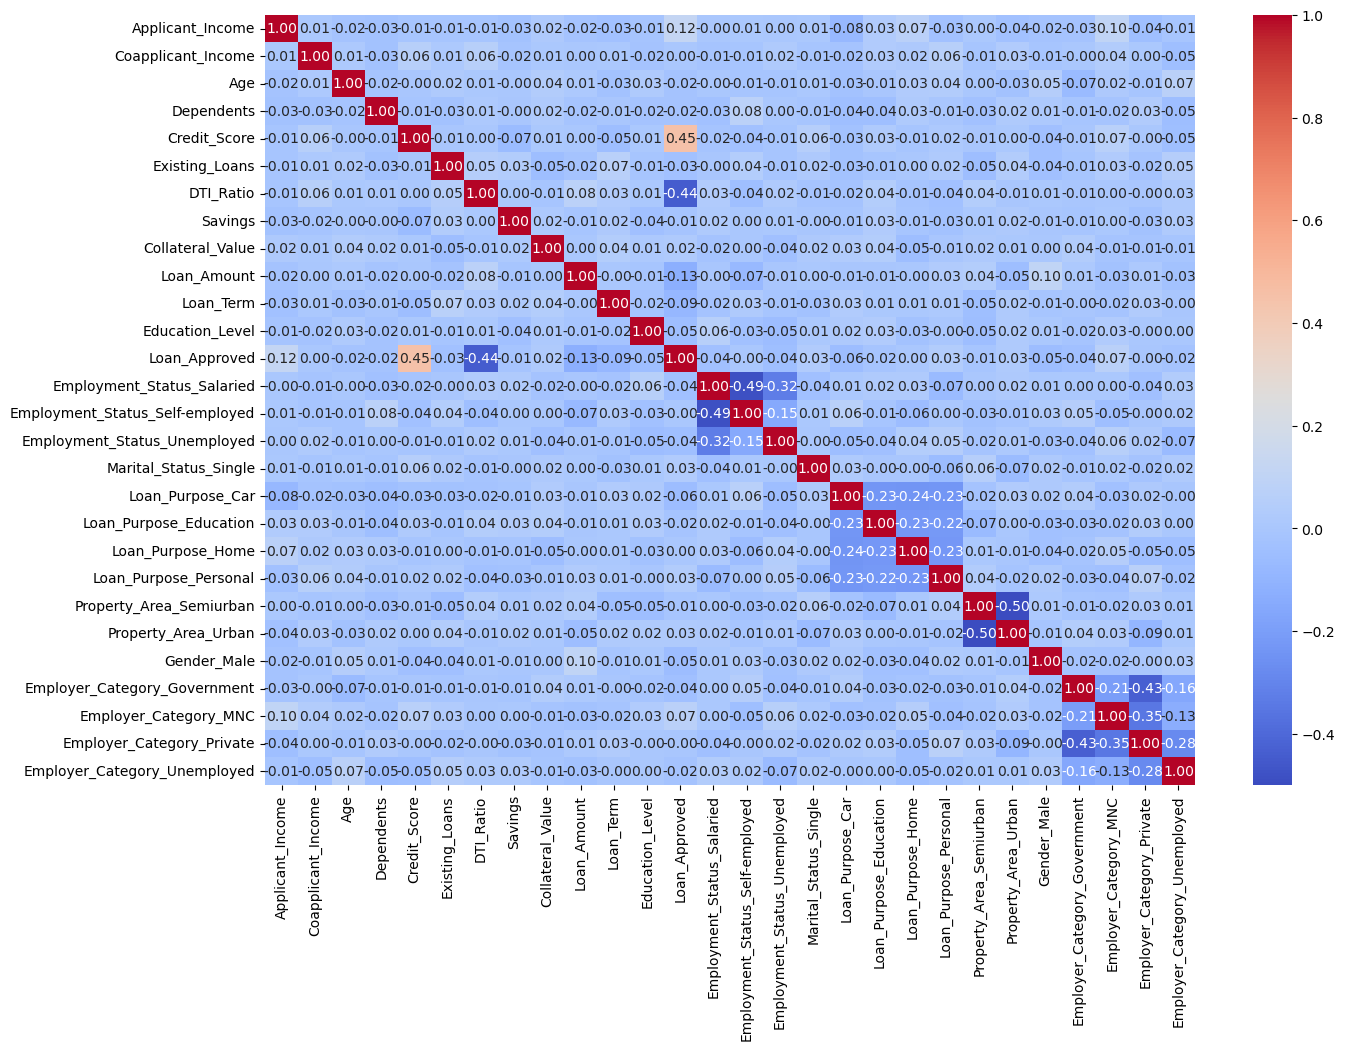

In [19]:
num_cols = df.select_dtypes(include= "number")
corr_matrix = num_cols.corr()

plt.figure(figsize = (15, 10))
sns.heatmap(
    corr_matrix,
    annot= True,
    fmt= "0.2f",
    cmap= "coolwarm"
)

### Feature Engineering

In [22]:
#Transform features

df["Credit_Score_sq"] = df["Credit_Score"] ** 2
df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2


### Test-Split and Feature Scaling

In [24]:
X = df.drop(columns= ["Loan_Approved", "Credit_Score", "DTI_Ratio", "Applicant_Income"])
y = df["Loan_Approved"]

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.2, random_state= 42
)

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

### Train and Evaluate Models

In [28]:
# Logistic regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

lr = LogisticRegression(max_iter = 1000)
lr.fit(X_train_scaler, y_train)

y_pred = lr.predict(X_test_scaler)

# Evaluation

print("Accuracy : ", accuracy_score(y_test, y_pred))
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print("F1_score : ", f1_score(y_test, y_pred))
print("Confusion_matrix : ", confusion_matrix(y_test, y_pred))


Accuracy :  0.855
Precision :  0.75
Recall :  0.7868852459016393
F1_score :  0.768
Confusion_matrix :  [[123  16]
 [ 13  48]]


In [29]:
# KNN

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

knn = KNeighborsClassifier(n_neighbors= 5)
knn.fit(X_train_scaler, y_train)

y_pred = knn.predict(X_test_scaler)

# Evaluation

print("Accuracy : ", accuracy_score(y_test, y_pred))
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print("F1_score : ", f1_score(y_test, y_pred))
print("Confusion_matrix : ", confusion_matrix(y_test, y_pred))


Accuracy :  0.755
Precision :  0.625
Recall :  0.4918032786885246
F1_score :  0.5504587155963303
Confusion_matrix :  [[121  18]
 [ 31  30]]


In [30]:
# Naive Bayes (Best on the basis of Precision)

from sklearn.naive_bayes import GaussianNB

naive = GaussianNB()
naive.fit(X_train_scaler, y_train)

# Evaluation

print("Accuracy : ", accuracy_score(y_test, y_pred))
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print("F1_score : ", f1_score(y_test, y_pred))
print("Confusion_matrix : ", confusion_matrix(y_test, y_pred))


Accuracy :  0.755
Precision :  0.625
Recall :  0.4918032786885246
F1_score :  0.5504587155963303
Confusion_matrix :  [[121  18]
 [ 31  30]]
